In [1]:
cd ..

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
pwd

'/home/mscs/congfeng4/GuidedStudy/Code/SCOIT'

In [3]:
import numpy as np
import pandas as pd
import time
import seaborn as sns
import hypernetx as hnx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import time

from hgnn.hypergraph import load_graph, load_graph_metadata

In [5]:
df = load_graph_metadata(Path('./data'))
df.to_csv('./data/graph_metadata.csv', index=False)
df = pd.read_csv('./data/graph_metadata.csv')

Found dataset: sc_GEM
Found dataset: PEA_STA
Found dataset: sci_CAR
Found dataset: SCoPE2
Found dataset: SNARE_seq_adult_mouse
Found dataset: SNARE_seq_neonatal_mouse
Found dataset: CITE_seq


In [57]:
df.set_index('dataname').sort_values('num_nodes num_edges'.split(), ascending=True)

,num_cells,num_genes,num_omics,num_nodes,num_edges
dataname,,,,,
sc_GEM,224,61,2,287,6805
PEA_STA,210,166,2,378,9977
SNARE_seq_neonatal_mouse,5081,100,2,5183,493974
SCoPE2,1490,5314,2,6806,7910930
sci_CAR,8837,100,2,8939,834002
SNARE_seq_adult_mouse,10309,100,2,10411,989347
CITE_seq,8617,36293,2,44912,302656631


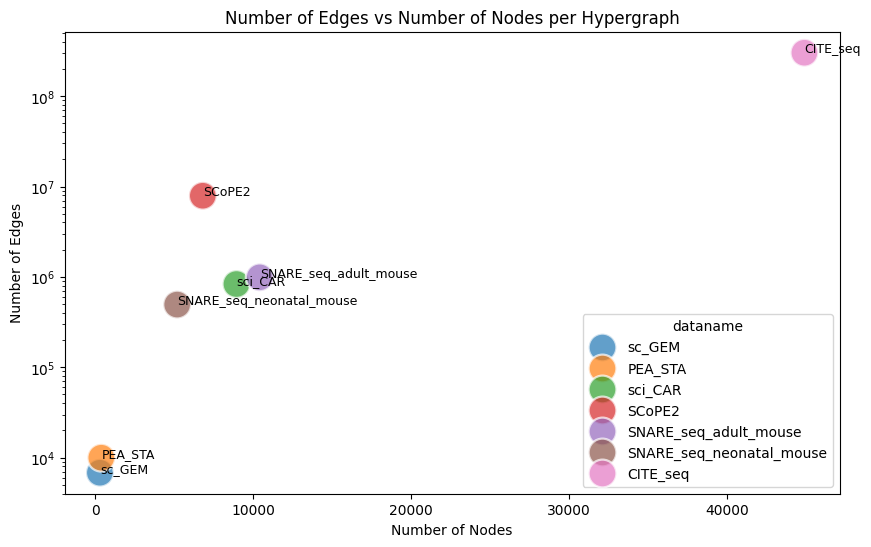

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot num_edges vs num_cells
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="num_nodes", y="num_edges", hue="dataname", s=400, alpha=0.7)
plt.yscale("log")
plt.title("Number of Edges vs Number of Nodes per Hypergraph")
plt.xlabel("Number of Nodes")
plt.ylabel("Number of Edges")

# Add text labels to each point
for idx, row in df.iterrows():
    # Place text slightly offset from the point to avoid overlap
    plt.text(
        x=row["num_nodes"] + 10,  # X-position (offset by 10 for readability)
        y=row["num_edges"] + 100, # Y-position (offset by 100)
        s=row["dataname"],        # Text to display (e.g., dataname)
        fontsize=9,
        color="black"
    )

plt.show()

In [59]:
df_long = df.melt(id_vars=['dataname'], value_vars=['num_nodes', 'num_edges', 'num_cells', 'num_genes', 'num_omics'],
                   var_name='type', value_name='count')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'sc_GEM'),
  Text(1, 0, 'PEA_STA'),
  Text(2, 0, 'sci_CAR'),
  Text(3, 0, 'SCoPE2'),
  Text(4, 0, 'SNARE_seq_adult_mouse'),
  Text(5, 0, 'SNARE_seq_neonatal_mouse'),
  Text(6, 0, 'CITE_seq')])

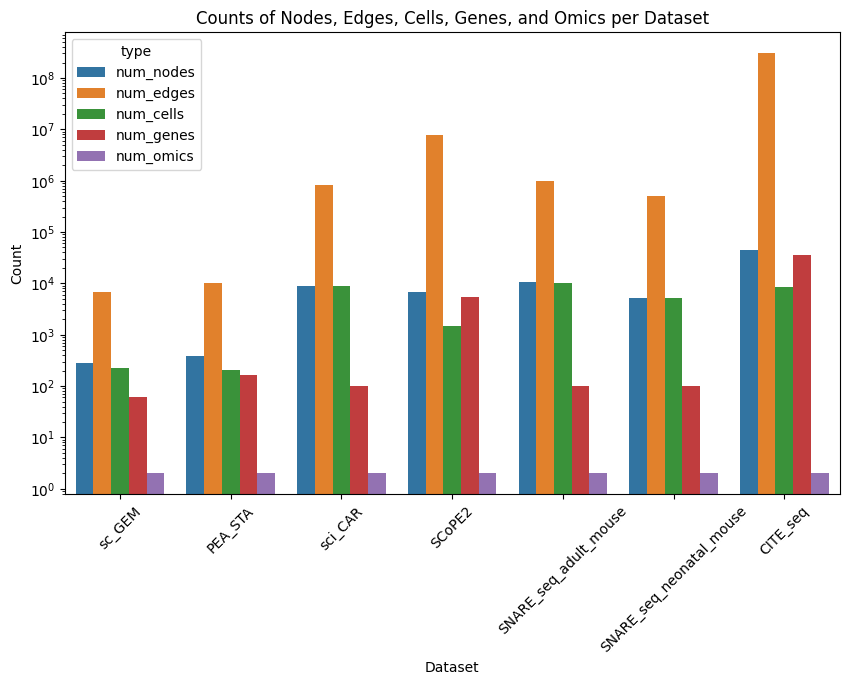

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_long, x='dataname', y='count', hue='type')
plt.yscale("log")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.title("Counts of Nodes, Edges, Cells, Genes, and Omics per Dataset")
plt.xticks(rotation=45)

In [7]:
g = load_graph(Path('./data/PEA_STA'))
print(g)

Load edges in 0.00 seconds.
Load nodes in 0.00 seconds.
Num nodes: 378, Num edges: 9977
Detected isolated ndoes {64, 5, 69, 39, 71, 138, 61, 85, 87, 28, 29, 63}


AssertionError: 

In [4]:
g = load_graph(Path('./data/sc_GEM'))
print(g)

Load edges in 0.01 seconds.
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: 13664
Metadata: {'dataname': 'sc_GEM', 'filter_edge': False, 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'orig_edges': 13664, 'num_edges': 13664, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID'}
HyperGraph(num_nodes=287, num_edges=13664)


In [8]:
g = load_graph(Path('./data/sci_CAR'))
print(g)

Load edges in 0.24 seconds.
Load nodes in 0.01 seconds.
Num nodes: 8939, Num edges: 834002
Metadata: {'dataname': 'sci_CAR', 'filter_edge': 'robust-zscore', 'num_cells': 8837, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 8939, 'orig_edges': 883700, 'num_edges': 834002, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/sci_CAR/ATAC_lsi.csv', 'rna': './data/sci_CAR/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=8939, num_edges=834002)


In [11]:
g = load_graph(Path('./data/SCoPE2'))
print(g)

Load edges in 1.78 seconds.
Load nodes in 0.01 seconds.
Num nodes: 6806, Num edges: 7910930
Metadata: {'dataname': 'SCoPE2', 'filter_edge': 'robust-zscore', 'num_cells': 1490, 'num_genes': 5314, 'num_omics': 2, 'num_nodes': 6806, 'orig_edges': 7917860, 'num_edges': 7910930, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 5316, 'raw_data': {'expr': './data/SCoPE2/expression_data.csv', 'protein': './data/SCoPE2/protein_data.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=6806, num_edges=7910930)


In [13]:
g = load_graph(Path('./data/SNARE_seq_adult_mouse'))
print(g)

Load edges in 0.27 seconds.
Load nodes in 0.01 seconds.
Num nodes: 10411, Num edges: 989347
Metadata: {'dataname': 'SNARE_seq_adult_mouse', 'filter_edge': 'robust-zscore', 'num_cells': 10309, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 10411, 'orig_edges': 1030900, 'num_edges': 989347, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/SNARE_seq_adult_mouse/ATAC_lsi.csv', 'rna': './data/SNARE_seq_adult_mouse/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=10411, num_edges=989347)


In [14]:
g = load_graph(Path('./data/SNARE_seq_neonatal_mouse'))
print(g)

Load edges in 0.12 seconds.
Load nodes in 0.00 seconds.
Num nodes: 5183, Num edges: 493974
Metadata: {'dataname': 'SNARE_seq_neonatal_mouse', 'filter_edge': 'robust-zscore', 'num_cells': 5081, 'num_genes': 100, 'num_omics': 2, 'num_nodes': 5183, 'orig_edges': 508100, 'num_edges': 493974, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 102, 'raw_data': {'atac': './data/SNARE_seq_neonatal_mouse/ATAC_lsi.csv', 'rna': './data/SNARE_seq_neonatal_mouse/RNA_pca.csv'}, 'cell_key': 'Unnamed: 0'}
HyperGraph(num_nodes=5183, num_edges=493974)


In [15]:
g = load_graph(Path('./data/CITE_seq'))
print(g)

Load edges in 4.59 seconds.
Load nodes in 0.02 seconds.
Num nodes: 44912, Num edges: 302656631
Metadata: {'dataname': 'CITE_seq', 'filter_edge': 'robust-zscore', 'num_cells': 8617, 'num_genes': 36293, 'num_omics': 2, 'num_nodes': 44912, 'orig_edges': 312736781, 'num_edges': 302656631, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 36295, 'raw_data': {'expr': './data/CITE_seq/expression_data.csv', 'protein': './data/CITE_seq/protein_data.csv'}, 'cell_key': 'cell ID'}
HyperGraph(num_nodes=44912, num_edges=302656631)
